In [15]:
# Bank Marketing Campaign 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#create dataset
np.random.seed(42)
n = 1000

jobs     = ['admin.','technician','services','management','retired',
            'blue-collar','unemployed','entrepreneur','student']
marital  = ['married','single','divorced']
education= ['primary','secondary','tertiary']

df = pd.DataFrame({
    'age'      : np.random.randint(18, 70, n),
    'job'      : np.random.choice(jobs, n),
    'marital'  : np.random.choice(marital, n),
    'education': np.random.choice(education, n),
    'default'  : np.random.choice(['yes','no'], n, p=[0.02, 0.98]),
    'balance'  : np.random.randint(-500, 10000, n),
    'housing'  : np.random.choice(['yes','no'], n),
    'loan'     : np.random.choice(['yes','no'], n, p=[0.16, 0.84]),
    'duration' : np.random.randint(10, 800, n),
    'campaign' : np.random.randint(1, 10, n),
    'y'        : np.random.choice(['yes','no'], n, p=[0.12, 0.88])
})

print(df.shape)
print(df.head())
print(df['y'].value_counts())

(1000, 11)
   age         job   marital  education default  balance housing loan  \
0   56    services  divorced  secondary      no     7595      no   no   
1   69    services  divorced   tertiary      no     5765      no  yes   
2   46     student  divorced   tertiary      no     9783      no   no   
3   32  unemployed  divorced   tertiary      no     1395     yes   no   
4   60     retired    single   tertiary      no     6024     yes   no   

   duration  campaign    y  
0       513         6   no  
1       715         4   no  
2       132         1   no  
3       657         1  yes  
4       422         5  yes  
y
no     875
yes    125
Name: count, dtype: int64


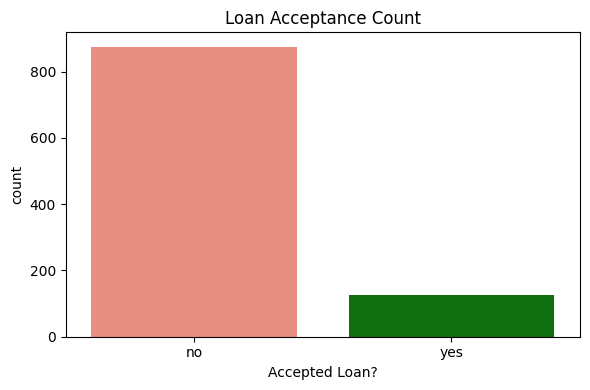

In [16]:
# Data Exploration & Visualization

#Target Balance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y',
              hue='y', palette={'yes':'green','no':'salmon'},
              legend=False)
plt.title('Loan Acceptance Count')
plt.xlabel('Accepted Loan?')
plt.tight_layout()
plt.show()

In [10]:
#Age Distribution by Acceptance
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='age', hue='y',
             bins=30, kde=True,
             palette={'yes':'green','no':'salmon'})
plt.title('Age Distribution by Loan Acceptance')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 900x500 with 0 Axes>

In [11]:
#Job vs Acceptance
plt.figure(figsize=(12, 5))
job_accept = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=False)

sns.barplot(x=job_accept.index, y=job_accept.values,
            hue=job_accept.index, palette='viridis', legend=False)
plt.title('Loan Acceptance Rate by Job Type (%)')
plt.xlabel('Job')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 1200x500 with 0 Axes>

In [12]:
#Marital Status vs Acceptance
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='marital', hue='y',
              palette={'yes':'green','no':'salmon'})
plt.title('Loan Acceptance by Marital Status')
plt.xlabel('Marital Status')
plt.legend(title='Accepted?')
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 700x500 with 0 Axes>

In [13]:
#Clean & Encode
df_model = df.copy()

# Encode target first
df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})

# Identify text columns
cat_cols = df_model.select_dtypes(include='object').columns
print("Categorical columns:", cat_cols)

# Label encode all text columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print(df_model.head())

Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan'], dtype='object')


NameError: name 'LabelEncoder' is not defined

In [14]:
#Split Features & Target
X = df_model.drop('y', axis=1)
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    # stratify=y keeps same yes/no ratio in train & test
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

NameError: name 'train_test_split' is not defined

In [11]:
#Scale Features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [13]:
# Train Both Models

#Logistic Regression
# Use class_weight='balanced' — tells the model to pay more attention to minority class
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("=== Logistic Regression (Balanced) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, zero_division=0))

=== Logistic Regression (Balanced) ===
Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.86      0.51      0.64       175
           1       0.11      0.44      0.18        25

    accuracy                           0.50       200
   macro avg       0.49      0.47      0.41       200
weighted avg       0.77      0.50      0.58       200



In [14]:
#Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree (Balanced) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0))


=== Decision Tree (Balanced) ===
Accuracy: 0.645
              precision    recall  f1-score   support

           0       0.86      0.71      0.78       175
           1       0.09      0.20      0.12        25

    accuracy                           0.65       200
   macro avg       0.48      0.45      0.45       200
weighted avg       0.76      0.65      0.70       200



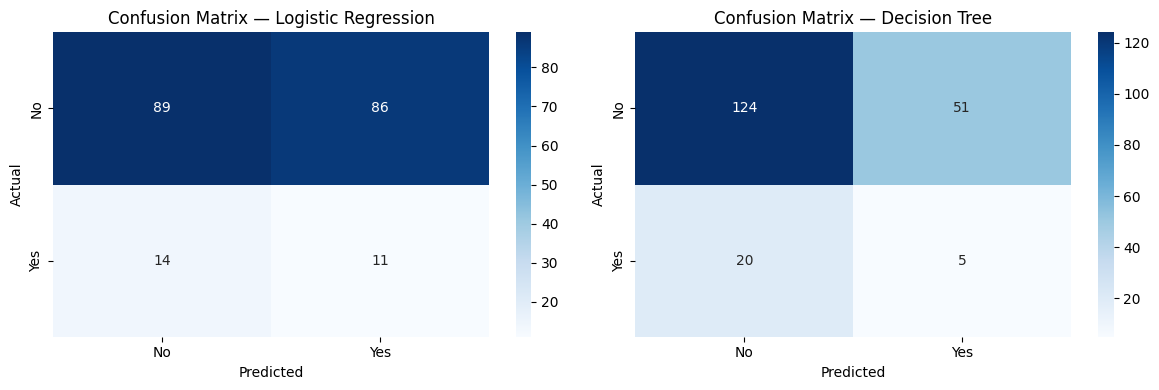

In [15]:
#Confusion Matrix (Both Models)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                             [y_pred_lr, y_pred_dt],
                             ['Logistic Regression', 'Decision Tree']):
    sns.heatmap(confusion_matrix(y_test, preds),
                annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No','Yes'],
                yticklabels=['No','Yes'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

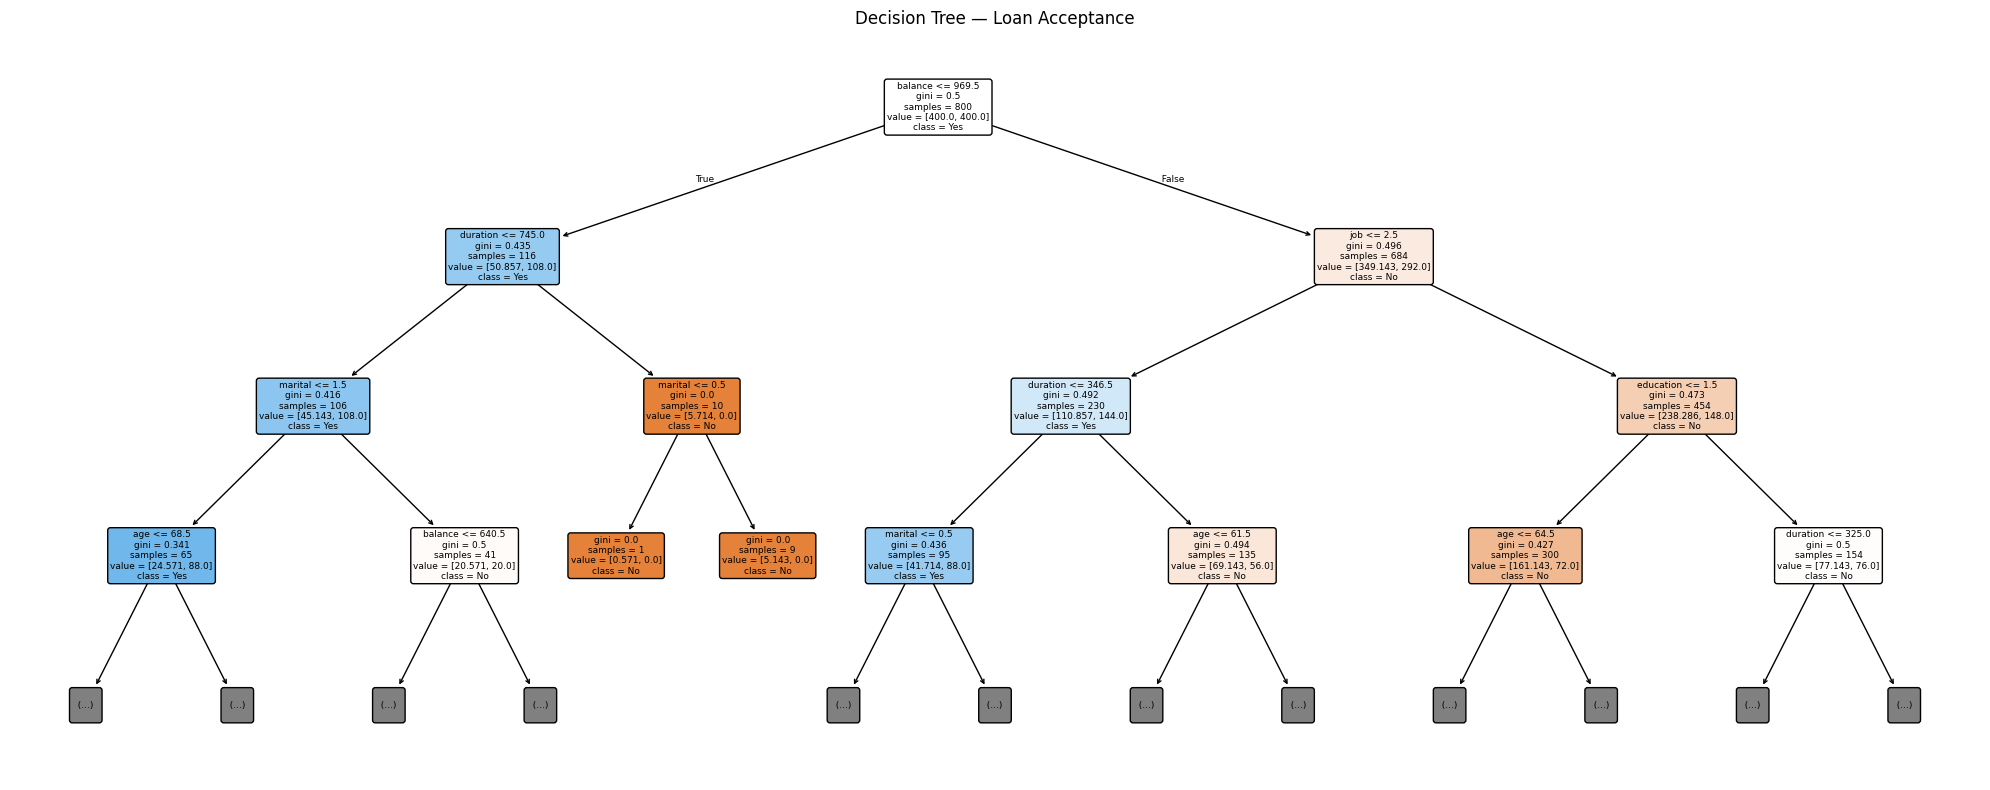

In [16]:
# Visualize Decision Tree
plt.figure(figsize=(20, 8))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          max_depth=3)       # Show top 3 levels only
plt.title('Decision Tree — Loan Acceptance')
plt.tight_layout()
plt.show()

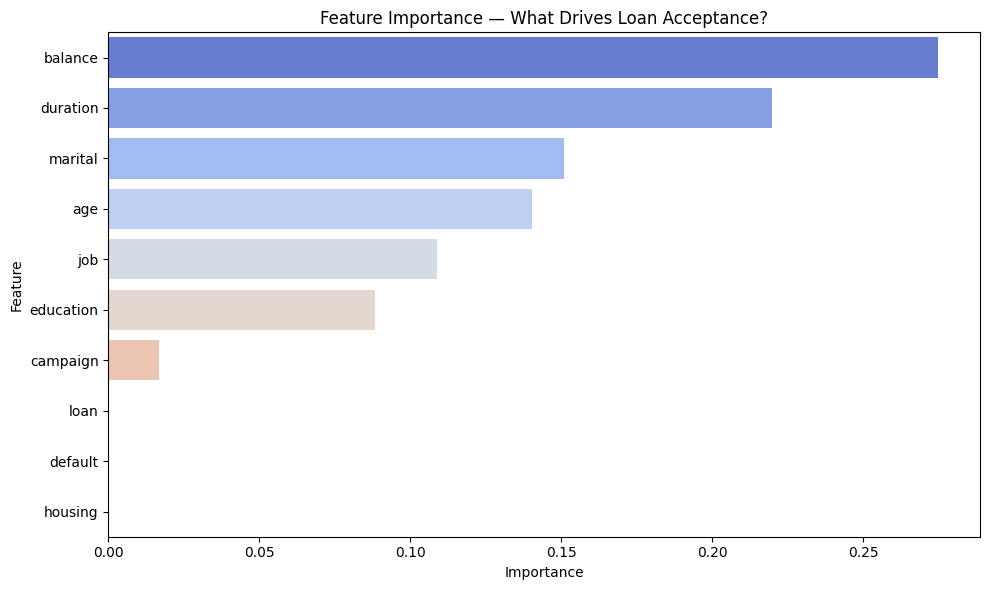

In [17]:
#Feature Importance (Decision Tree)
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature',
            hue='Feature', palette='coolwarm', legend=False)
plt.title('Feature Importance — What Drives Loan Acceptance?')
plt.tight_layout()
plt.show()